First 5 rows of the dataset:
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Missing values in each column:
Category    0
Message     0
dtype: int64

Accuracy: 0.9739910313901345

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



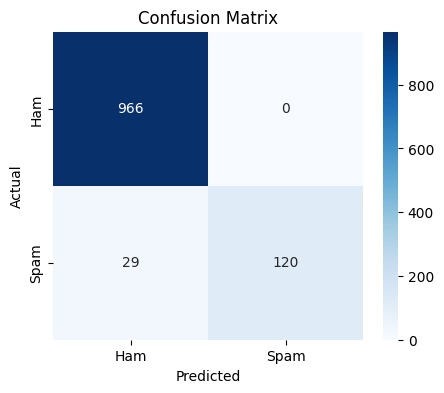

In [3]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("email.csv")

# Check Dataset
print("First 5 rows of the dataset:")
print(df.head())

print("\nMissing values in each column:")
print(df.isnull().sum())

# Data Cleaning
df = df.dropna(subset=['Category', 'Message'])

# Standardize Category column
df['Category'] = df['Category'].str.lower()

# Keep only valid labels
df = df[df['Category'].isin(['ham', 'spam'])]

# Rename Columns & Encode Labels
df.rename(columns={'Category': 'label', 'Message': 'text'}, inplace=True)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['text']
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Text Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Naive Bayes Model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predictions on Test Set
y_pred = model.predict(X_test_vec)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [4]:
# Test a New Email

def predict_email(email_text):
    email_vec = vectorizer.transform([email_text])
    prediction = model.predict(email_vec)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

test_email = "Hi team, please remember we have a project meeting scheduled tomorrow at 10 AM. Don't forget to bring your reports."

result = predict_email(test_email)
print("Email Text:", test_email)
print("Prediction:", result)


Email Text: Hi team, please remember we have a project meeting scheduled tomorrow at 10 AM. Don't forget to bring your reports.
Prediction: HAM


In [6]:
import joblib

# Save model and vectorizer
joblib.dump(model, "spam or ham Email model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
